In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



In [ ]:
!pip install gdown
import gdown

In [ ]:
file_id = '1FK_hpKTrLVRSdxxXRTVlrBOTRWkHFUbj'
gdrive_url = f'https://drive.google.com/uc?id={file_id}'
output = 'new_airbnb.csv'
# Download the file
gdown.download(gdrive_url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1FK_hpKTrLVRSdxxXRTVlrBOTRWkHFUbj
To: /content/new_airbnb.csv
100%|██████████| 1.32M/1.32M [00:00<00:00, 28.2MB/s]


'new_airbnb.csv'

In [ ]:
# Read the CSV file into a DataFrame
df = pd.read_csv(output)

In [ ]:
df.head()

,id,name,rating,reviews,bathrooms,beds,guests,toilets,bedrooms,studios,checkin,checkout,host_id,country,family_suitability,price_fix,safety,natural_condition,work_suitability
0,49849504,Perla bungalov,4,64,1,1,2,0,2,0,3,2,357334205.0,Turkey,2,269.0,1,3,1
1,50891766,Authentic Beach Architect Sheltered Villa with...,0,0,2,2,4,0,2,0,2,1,386223873.0,Turkey,1,156.0,1,0,2
2,50699164,cottages sataplia,4,68,1,3,4,0,1,0,2,2,409690853.0,Georgia,2,200.0,2,1,2
3,49871422,Sapanca Breathable Bungalow,5,13,1,2,4,0,1,0,2,2,401873242.0,Turkey,0,378.0,3,2,1
4,51245886,Bungalov Ev 2,0,0,1,1,2,0,1,0,2,2,414884116.0,Turkey,1,222.0,1,0,2


In [ ]:
df['country'].unique()

array(['Turkey', 'Georgia', 'Vietnam', 'Thailand', 'South Korea', 'India',
       'Philippines', 'Japan', 'Lebanon', 'Taiwan', 'Israel', 'Armenia',
       'Cyprus', 'Lithuania', 'Slovakia', 'Denmark', 'Germany',
       'Indonesia', 'Poland', 'Romania', 'Greece', 'Ukraine', 'Hungary',
       'Albania', 'Bulgaria', 'Malaysia', 'Montenegro', 'Slovenia',
       'Czechia', 'Sweden', 'Austria', 'Croatia', 'Tanzania', 'Italy',
       'Sri Lanka', 'Bosnia & Herzegovina', 'Kenya', 'Serbia',
       'Seychelles', 'Finland', 'Norway', 'Iceland', 'Greenland',
       'United States', 'Canada', 'Svalbard & Jan Mayen', 'France',
       'Australia', 'Morocco', 'Egypt', 'South Africa', 'Spain',
       'United Arab Emirates', 'United Kingdom', 'Pakistan', 'Nepal',
       'Singapore', 'Cambodia', 'Azerbaijan', 'Estonia', 'Latvia',
       'Costa Rica', 'Netherlands', 'Portugal', 'New Zealand', 'Panama',
       'Mexico', 'Peru', 'Chile', 'Belize', 'Colombia', 'Switzerland',
       'Ireland', 'Bolivia', 'Bel

In [ ]:
df['guests'].max()

16

In [ ]:
df['price_fix'].max()

63599.0

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12805 entries, 0 to 12804
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  12805 non-null  int64  
 1   name                12805 non-null  object 
 2   rating              12805 non-null  int64  
 3   reviews             12805 non-null  int64  
 4   bathrooms           12805 non-null  int64  
 5   beds                12805 non-null  int64  
 6   guests              12805 non-null  int64  
 7   toilets             12805 non-null  int64  
 8   bedrooms            12805 non-null  int64  
 9   studios             12805 non-null  int64  
 10  checkin             12805 non-null  int64  
 11  checkout            12805 non-null  int64  
 12  host_id             12805 non-null  float64
 13  country             12805 non-null  object 
 14  family_suitability  12805 non-null  int64  
 15  price_fix           12805 non-null  float64
 16  safe

In [ ]:
STOP

NameError: name 'STOP' is not defined

## Weighted Rating Recommendation System

In [ ]:
# Calculate C (mean rating across all listings)
C = df['rating'].mean()

# Calculate m (minimum number of reviews required to be listed)
m = df['reviews'].quantile(0.9)

In [ ]:
# Filter listings that qualify (have reviews >= m)
q_listings = df.copy().loc[df['reviews'] >= m]
print(q_listings.shape)

(1284, 19)


In [ ]:
country_input = input('Enter country:').strip().lower()

Enter country:indonesia


In [ ]:
min_price = int(input('Enter minimum price:'))

Enter minimum price:200


In [ ]:
max_price = int(input('Enter maximum price:'))

Enter maximum price:300


In [ ]:
# Choose preferences for each amenity
family_suitability_input = int(input("Enter family suitability level (0-5):"))
safety_input = int(input("Enter safety level (0-7):"))
natural_condition_input = int(input("Enter natural condition level (0-3):"))
work_suitability_input = int(input("Enter work suitability level (0-3):"))

Enter family suitability level (0-5):0
Enter safety level (0-7):1
Enter natural condition level (0-3):3
Enter work suitability level (0-3):4


In [ ]:
# Filter DataFrame based on inputs
filtered_listings = df[df['country'].str.lower() == country_input]
filtered_listings = filtered_listings[(filtered_listings['price_fix'] >= min_price) & (filtered_listings['price_fix'] <= max_price)]


In [ ]:
# Calculate the absolute differences between the amenities preferences and the listings
filtered_listings['family_diff'] = np.abs(filtered_listings['family_suitability'] - family_suitability_input)
filtered_listings['safety_diff'] = np.abs(filtered_listings['safety'] - safety_input)
filtered_listings['natural_diff'] = np.abs(filtered_listings['natural_condition'] - natural_condition_input)
filtered_listings['work_diff'] = np.abs(filtered_listings['work_suitability'] - work_suitability_input)

In [ ]:
# Calculate a total "distance" score from the user's preferences (sum of differences)
filtered_listings['total_diff'] = (filtered_listings['family_diff'] +
                                   filtered_listings['safety_diff'] +
                                   filtered_listings['work_diff'])

In [ ]:
# Define weighted score (customize the weights based on your preferences)
filtered_listings['weighted_score'] = (
    (filtered_listings['rating'] * 0.4) +  # 50% weight for rating
    (filtered_listings['reviews'] * 0.3) +  # 30% weight for reviews
    (filtered_listings['price_fix'] * 0.2)  # 20% weight for price
)

In [ ]:
# Sort by the smallest "total_diff" to get listings that are closest to the user's preferences
sorted_listings = filtered_listings.sort_values(by='weighted_score')

In [ ]:
# Select the top 10 listings
top_listings = sorted_listings[['id', 'name', 'reviews', 'rating', 'price_fix', 'country',
                                'family_suitability', 'safety', 'natural_condition', 'work_suitability']].head(10)

In [ ]:
# Display the top listings
top_listings

,id,name,reviews,rating,price_fix,country,family_suitability,safety,natural_condition,work_suitability
2123,27869783,Bali Natha Bungalows Canggu (Garden View),5,5,202.0,Indonesia,2,1,0,1
2197,44315574,Villa Shanti from Same,4,5,204.0,Indonesia,2,0,0,2
135,42164569,Superior Bungalow 02,0,0,225.0,Indonesia,0,1,0,2
10801,619195437162834699,Paralia Premium Customized Room Sanur District,0,0,225.0,Indonesia,1,3,1,3
1179,45167632,Wooden House in the Mountains - Kledung Tiny H...,8,5,211.0,Indonesia,0,1,1,1
12754,41804805,Bubble Tent around Yogyakarta city,1,0,238.0,Indonesia,0,3,0,0
9758,50649065,Ketapang Resort (Tree House Kayu),3,5,235.0,Indonesia,1,1,0,2
10710,539042054840907108,Soundproof music studio with a classic feel,0,0,256.0,Indonesia,0,2,0,2
12732,624427228585355259,Kintamani Glamping Black Lava Camp Potato 9,1,0,266.0,Indonesia,0,1,0,0
5582,34345106,PIUGUS RESORT (STANDARD-02),0,0,270.0,Indonesia,1,1,0,1


#User Dummy


In [ ]:
# Ask user to select listings by ID (or you can choose an index if more appropriate)
chosen_ids = input("Enter the IDs of the listings you want to book (comma-separated): ").split(',')


Enter the IDs of the listings you want to book (comma-separated): 34345106


In [ ]:
# Convert chosen IDs to integers
chosen_ids = [int(x.strip()) for x in chosen_ids]

# Create an empty DataFrame to store chosen listings (dummy user data)
dummy_user_data = pd.DataFrame()


In [ ]:

# Append the selected listings to the dummy user data
for listing_id in chosen_ids:
    chosen_listing = top_listings[top_listings['id'] == listing_id]
    user_data = pd.concat([dummy_user_data, chosen_listing], ignore_index=True)


In [ ]:
# Show the dummy user data
print("\nChosen Listings (Dummy User Data):")
user_data


Chosen Listings (Dummy User Data):


,id,name,reviews,rating,price_fix,country,family_suitability,safety,natural_condition,work_suitability
0,34345106,PIUGUS RESORT (STANDARD-02),0,0,270.0,Indonesia,1,1,0,1


In [ ]:
user_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1 non-null      int64  
 1   name                1 non-null      object 
 2   reviews             1 non-null      int64  
 3   rating              1 non-null      int64  
 4   price_fix           1 non-null      float64
 5   country             1 non-null      object 
 6   family_suitability  1 non-null      int64  
 7   safety              1 non-null      int64  
 8   natural_condition   1 non-null      int64  
 9   work_suitability    1 non-null      int64  
dtypes: float64(1), int64(7), object(2)
memory usage: 208.0+ bytes


#Clustering

##Features Selection


In [ ]:
# Dropping the 'id', 'host_id', 'cluster', and 'country' columns
new_df = df.drop(columns=['id','name', 'host_id', 'country', 'studios', 'checkin', 'checkout', 'toilets', 'price_fix','bedrooms','guests','rating','reviews'])  #'rating', 'reviews'

##Tuning


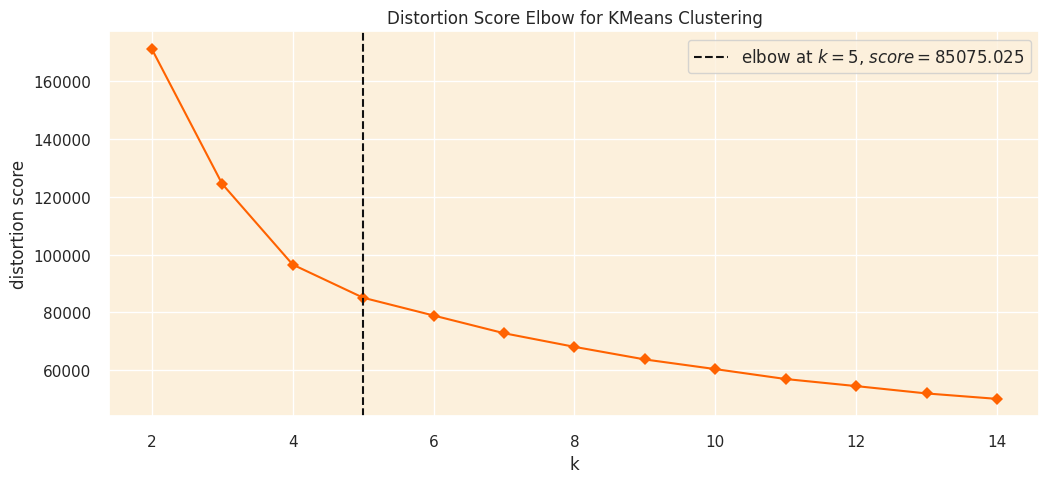

In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

# Set plot style, and background color
sns.set(style='darkgrid', rc={'axes.facecolor': '#fcf0dc'})

# Set the color palette for the plot
sns.set_palette(['#ff6200'])

# Instantiate the clustering model with the specified parameters
km = KMeans(init='k-means++', n_init=10, max_iter=100, random_state=0)

# Create a figure and axis with the desired size
fig, ax = plt.subplots(figsize=(12, 5))

# Instantiate the KElbowVisualizer with the model and range of k values, and disable the timing plot
visualizer = KElbowVisualizer(km, k=(2, 15), timings=False, ax=ax)


# Fit the data to the visualizer
visualizer.fit(new_df)

# Finalize and render the figure
visualizer.show();

In [ ]:
from sklearn.metrics import silhouette_score

range_n_clusters = list(range(2,11))
print(range_n_clusters)

[2, 3, 4, 5, 6, 7, 8, 9, 10]


In [ ]:
arr_silhouette_score_euclidean = []
for i in range_n_clusters:
    kmeans = KMeans(n_clusters=i).fit(new_df)
    preds = kmeans.predict(new_df)

    score_euclidean = silhouette_score(new_df, preds, metric='euclidean')
    arr_silhouette_score_euclidean.append(score_euclidean)

<Axes: >

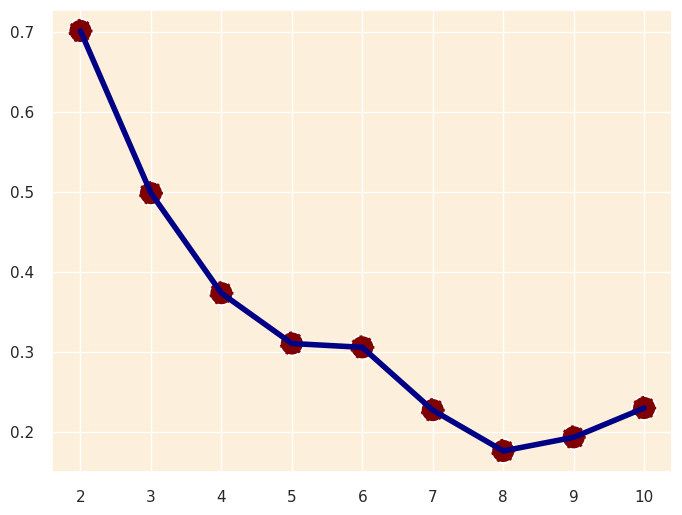

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(x=range(2,11), y=arr_silhouette_score_euclidean, color='#000087', linewidth = 4)
sns.scatterplot(x=range(2,11), y=arr_silhouette_score_euclidean, s=300, color='#800000',  linestyle='--')

## Fit Kmeans Cluster Model and Create Cluster Plot

In [ ]:
common_columns = ['beds',
                  'family_suitability', 'safety',
                  'natural_condition', 'work_suitability']

In [ ]:
import joblib
kmeans = KMeans(n_clusters=4, random_state=100, n_init=10)
cluster = kmeans.fit_predict(new_df[common_columns])
# Save the model to a file
joblib.dump(kmeans, 'kmeans_model.pkl')

['kmeans_model.pkl']

In [ ]:
# Add the cluster labels to the original dataframe
df['cluster'] = cluster

# Rename the dataframe with clusters as 'merged_df'
merged_df = df.copy()

<ipython-input-37-a7788ee56d2f>:14: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.scatterplot(


<Axes: xlabel='pc1', ylabel='pc2'>

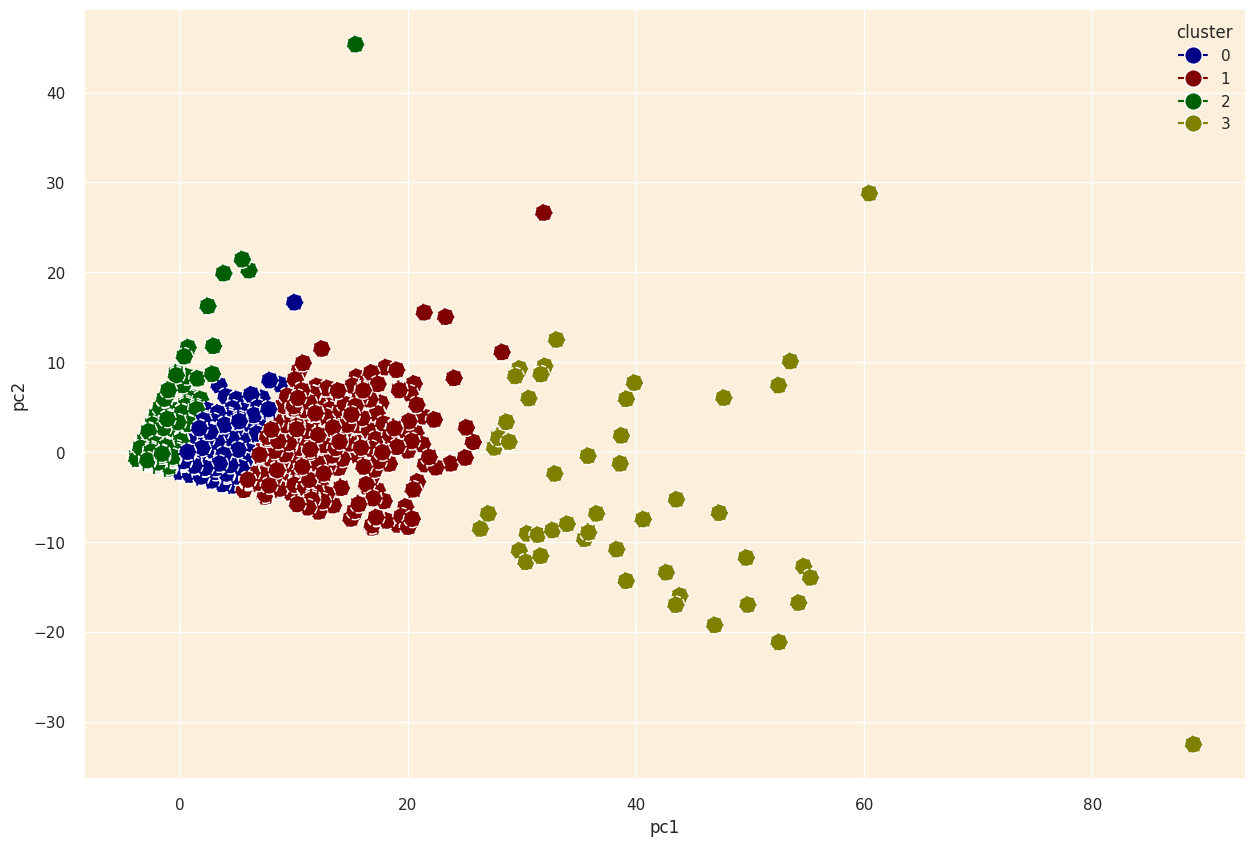

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(new_df)
pcs = pca.transform(new_df)

pca = pd.DataFrame(data = pcs, columns = ['pc1', 'pc2'])


pca['cluster'] = kmeans.labels_

fig, ax = plt.subplots(figsize=(15,10))

sns.scatterplot(
    x="pc1", y="pc2",
    hue="cluster",
    edgecolor='white',
    linestyle='--',
    data=pca,
    palette=['#000087','#800000','#005f00',"#808000",'#808080'],
    s=160,
    ax=ax
)


In [ ]:
# Define a custom mode function
def mode(series):
    return series.mode().iloc[0]

# Calculate the centroids for each cluster
centroid_df = df.groupby('cluster')[[ 'bathrooms', 'beds', 'guests',
                                         'bedrooms', 'family_suitability', 'safety',
                                         'natural_condition', 'work_suitability']].agg({


    'bathrooms': 'median',
    'beds': 'median',
    'guests': 'median',
    'bedrooms': 'median',
    'family_suitability': mode,
    'safety': 'median',
    'natural_condition': mode,
    'work_suitability': mode,
}).reset_index()

# Rename the 'id' column to 'num_listings'
centroid_df = centroid_df.rename(columns={'id': 'num_listings'})

centroid_df

,cluster,bathrooms,beds,guests,bedrooms,family_suitability,safety,natural_condition,work_suitability
0,0,2.0,5.0,8.0,3.0,1,1.0,0,2
1,1,5.0,12.0,16.0,7.0,1,1.0,0,2
2,2,1.0,2.0,3.0,1.0,1,1.0,0,2
3,3,9.0,40.0,16.0,19.0,1,1.0,0,1


In [ ]:
df['cluster'].value_counts()

,count
cluster,
2,9011
0,3135
1,608
3,51


In [ ]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12805 entries, 0 to 12804
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   bathrooms           12805 non-null  int64
 1   beds                12805 non-null  int64
 2   family_suitability  12805 non-null  int64
 3   safety              12805 non-null  int64
 4   natural_condition   12805 non-null  int64
 5   work_suitability    12805 non-null  int64
dtypes: int64(6)
memory usage: 600.4 KB


#Recommendation System


In [ ]:
user_data

,id,name,reviews,rating,price_fix,country,family_suitability,safety,natural_condition,work_suitability
0,34345106,PIUGUS RESORT (STANDARD-02),0,0,270.0,Indonesia,1,1,0,1


In [ ]:

# Step 2: Check if 'country' column is present
if 'country' not in merged_df.columns:
    print("Country column is missing. Ensure that listings_df contains the country data.")
else:
    # Step 3: Function to find similar listings based on cluster
    def recommend_based_on_cluster(user_data, merged_df, country_input):
        # Step 4: Normalize country input
        country_input = country_input.lower().strip()

        # Step 5: Filter merged_df based on the input country
        country_filtered_df = merged_df[merged_df['country'].str.lower().str.strip() == country_input]

        if country_filtered_df.empty:
            print(f"No listings found for country: {country_input}")
            return pd.DataFrame()

        # Step 6: Identify user's cluster features for comparison
        cluster_features = ['family_suitability', 'safety', 'natural_condition', 'work_suitability']
        user_cluster_features = user_data[cluster_features].values[0]

        # Step 7: Filter based on similar features
        similar_listings = country_filtered_df[
            (country_filtered_df[cluster_features] == user_cluster_features).all(axis=1)
        ]

        # Step 8: Exclude the user's own listing to avoid duplicate recommendation
        user_listing_id = user_data['id'].values[0]
        unique_listings = similar_listings[similar_listings['id'] != user_listing_id]

        if unique_listings.empty:
            print("No unique listings found with the exact features.")
            return pd.DataFrame()

        # Step 9: Sort listings by rating and reviews
        sorted_listings = unique_listings.sort_values(by=['rating', 'reviews'], ascending=[False, False])

        # Step 10: Ensure a minimum of 10 unique recommendations
        top_recommendations = sorted_listings[['name', 'rating', 'reviews', 'price_fix', 'country', 'cluster']].drop_duplicates()

        if len(top_recommendations) < 10:
            # If fewer than 10 recommendations, expand the search by loosening the criteria or using additional similar clusters
            print("Fewer than 10 recommendations found. Expanding search criteria...")

            # Example of relaxing the feature similarity criteria
            # For simplicity, let’s allow a broader similarity window or include nearby clusters if applicable.
            # Here, we are just including more listings from the same country without exact feature matching.

            # Additional filter to include more results
            broader_listings = country_filtered_df[
                country_filtered_df['id'] != user_listing_id
            ]
            broader_listings = broader_listings.sort_values(by=['rating', 'reviews'], ascending=[False, False])
            additional_recommendations = broader_listings[['name', 'rating', 'reviews', 'price_fix', 'country', 'cluster']].drop_duplicates().head(10 - len(top_recommendations))

            # Combine the original and additional recommendations
            top_recommendations = pd.concat([top_recommendations, additional_recommendations]).drop_duplicates().head(10)

        return top_recommendations

    # Example usage
    country_input = input('Enter country:').strip().lower()
    recommended_listings = recommend_based_on_cluster(user_data, merged_df, country_input )

# Output the result
recommended_listings

Enter country:indonesia


,name,rating,reviews,price_fix,country,cluster
9820,hars garden tree houses/love romantic,4,253,82.0,Indonesia,2
1479,Villa Akasha - Bio-Architected Eco Dome,4,238,228.0,Indonesia,2
2143,FELLA Luxury Beach Villa Canggu,4,216,680.0,Indonesia,2
2860,Barn Villa Lembang,4,136,568.0,Indonesia,0
2217,Semi Open Bungalow + Instagram Hammock Net,4,119,408.0,Indonesia,2
2115,Bali Bamboo House | Rescape Ubud - Relief Villa,4,100,245.0,Indonesia,2
2187,Experience Bali's amazing North-West in luxury,4,100,558.0,Indonesia,2
5533,PIUGUS RESORT (STANDARD-01),4,6,270.0,Indonesia,2
1232,Saung Room at Paddies Homestay,0,1,51.0,Indonesia,2
5556,PIUGUS RESORT (STANDARD-05),0,0,270.0,Indonesia,2


#Price Prediction

In [ ]:
df.head()

,id,name,rating,reviews,bathrooms,beds,guests,toilets,bedrooms,studios,checkin,checkout,host_id,country,family_suitability,price_fix,safety,natural_condition,work_suitability,cluster
0,49849504,Perla bungalov,4,64,1,1,2,0,2,0,3,2,357334205.0,Turkey,2,269.0,1,3,1,2
1,50891766,Authentic Beach Architect Sheltered Villa with...,0,0,2,2,4,0,2,0,2,1,386223873.0,Turkey,1,156.0,1,0,2,2
2,50699164,cottages sataplia,4,68,1,3,4,0,1,0,2,2,409690853.0,Georgia,2,200.0,2,1,2,2
3,49871422,Sapanca Breathable Bungalow,5,13,1,2,4,0,1,0,2,2,401873242.0,Turkey,0,378.0,3,2,1,2
4,51245886,Bungalov Ev 2,0,0,1,1,2,0,1,0,2,2,414884116.0,Turkey,1,222.0,1,0,2,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12805 entries, 0 to 12804
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  12805 non-null  int64  
 1   name                12805 non-null  object 
 2   rating              12805 non-null  int64  
 3   reviews             12805 non-null  int64  
 4   bathrooms           12805 non-null  int64  
 5   beds                12805 non-null  int64  
 6   guests              12805 non-null  int64  
 7   toilets             12805 non-null  int64  
 8   bedrooms            12805 non-null  int64  
 9   studios             12805 non-null  int64  
 10  checkin             12805 non-null  int64  
 11  checkout            12805 non-null  int64  
 12  host_id             12805 non-null  float64
 13  country             12805 non-null  object 
 14  family_suitability  12805 non-null  int64  
 15  price_fix           12805 non-null  float64
 16  safe

In [ ]:
df_predict = df.copy()

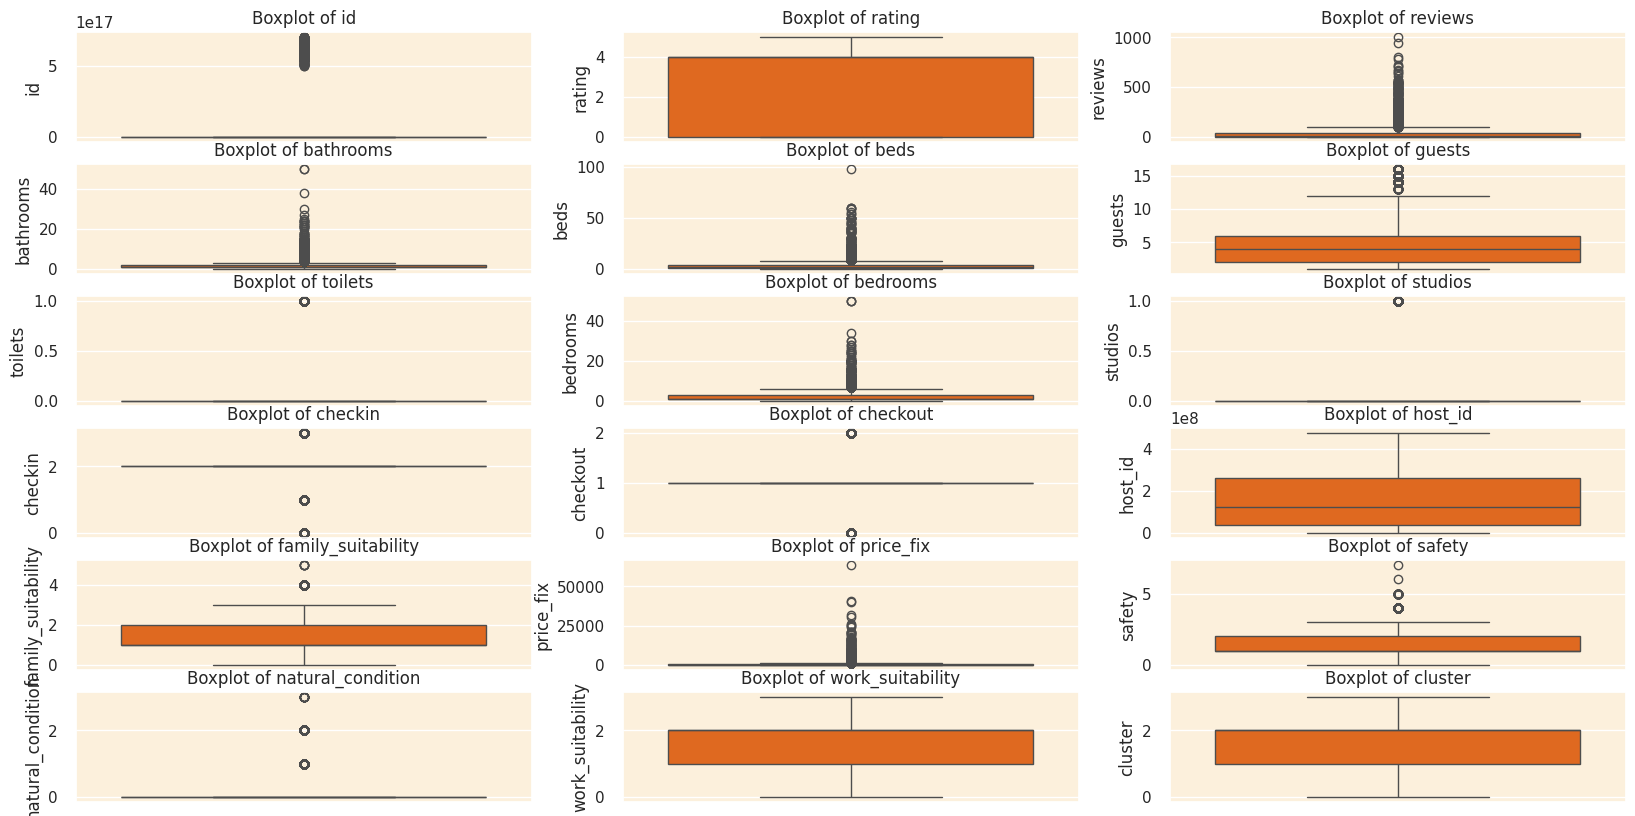

In [ ]:
# Filter the remaining numerical features
numerical_features = df_predict.select_dtypes(include = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']).columns
# Set up the matplotlib figure
plt.figure(figsize=(20, 10))

# Create boxplots for each feature
for i, feature in enumerate(numerical_features):
    plt.subplot(6, 3, i + 1)
    sns.boxplot(y=df_predict[feature])
    plt.title(f'Boxplot of {feature}')

In [ ]:
# Apply log transformation to reduce skewness
df_predict['price_fix'] = np.log1p(df_predict['price_fix'])

In [ ]:
# Handle outliers using log transformation
skewed_features = ['reviews']
skewed_features_2 = ['bedrooms','beds','bathrooms','price_fix','guests']
for feature in skewed_features:
    df_predict[feature] = np.log1p(df_predict[feature])

# Function to handle outliers based on quantiles
def handle_outliers_quantile(df_predict, feature, lower_percentile=0.05, upper_percentile=0.95):
    lower_bound =  df_predict[feature].quantile(lower_percentile)
    upper_bound =  df_predict[feature].quantile(upper_percentile)
    df_predict[feature] = np.where(df_predict[feature] < lower_bound, lower_bound, df_predict[feature])
    df_predict[feature] = np.where(df_predict[feature] > upper_bound, upper_bound, df_predict[feature])
for feature in skewed_features_2 :
    handle_outliers_quantile(df_predict, feature)


In [ ]:
# Reverse log transformation and scale the values back to the original range
df_predict['price_fix'] = np.expm1(df_predict['price_fix'])

# Optional: Apply a scaling factor to normalize the values further (if needed)
scaling_factor = 10  # Ensure price_fix is scaled to hundreds
df_predict['price_fix'] = df_predict['price_fix'] / scaling_factor


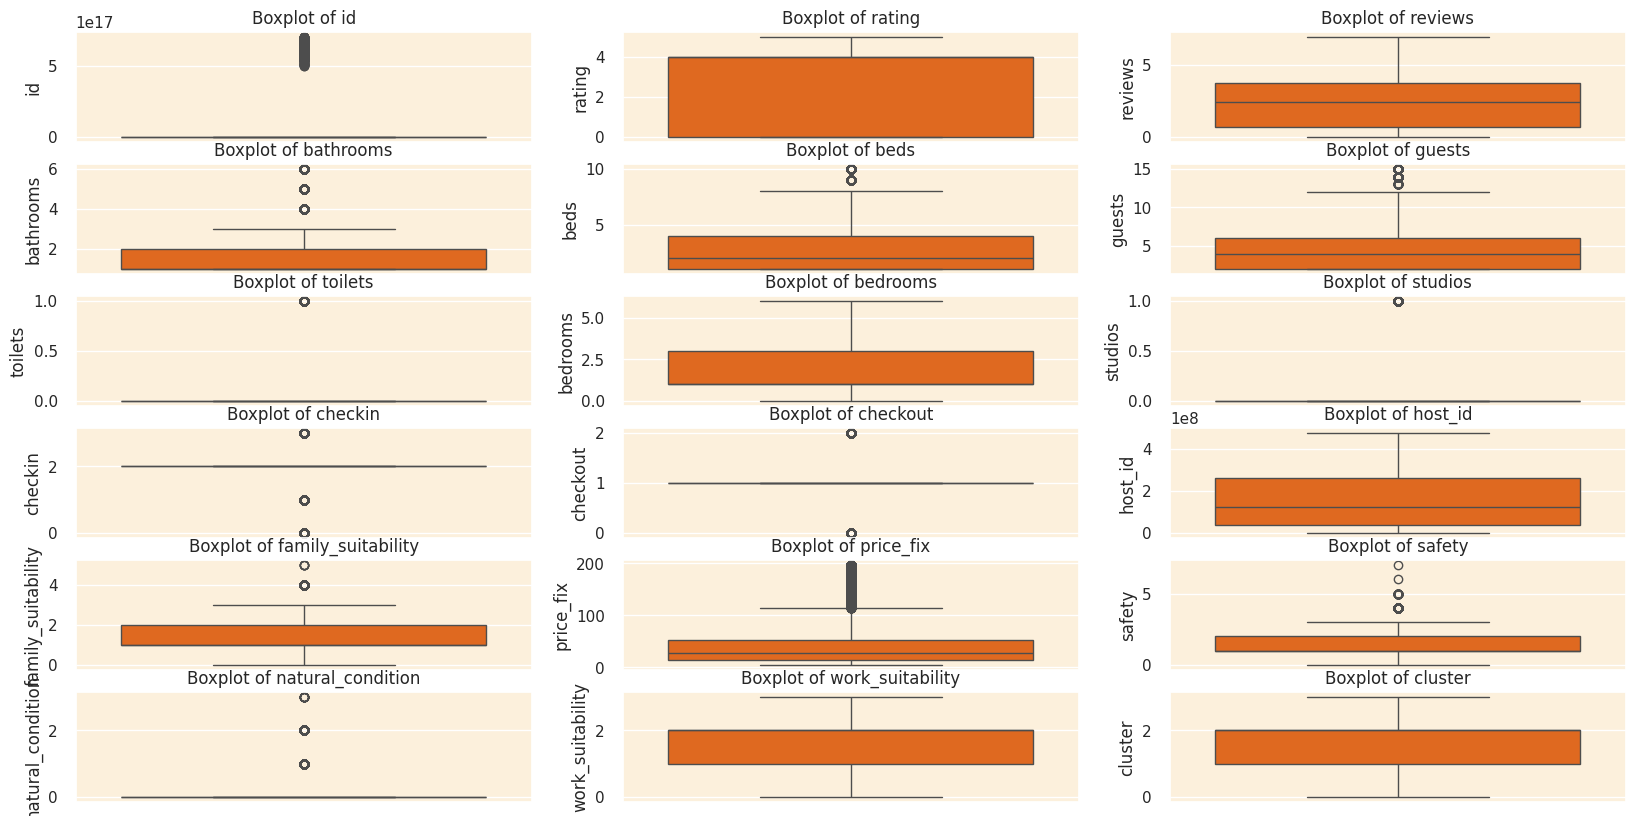

In [ ]:
# Set up the matplotlib figure
plt.figure(figsize=(20, 10))

# Create boxplots for each feature
for i, feature in enumerate(numerical_features):
    plt.subplot(6, 3, i + 1)
    sns.boxplot(y=df_predict[feature])
    plt.title(f'Boxplot of {feature}')



In [ ]:
# Calculate the mean price for each country
country_price_mean = df_predict.groupby('country')['price_fix'].median()
# Map the mean price to the country column
df_predict['country_encoded'] = df_predict['country'].map(country_price_mean)

# Display unique combinations of 'country' and 'country_encoded'
unique_country_encoded = df_predict[['country', 'country_encoded']].drop_duplicates()
unique_country_encoded.head(10)

,country,country_encoded
0,Turkey,46.30
2,Georgia,16.80
8,Vietnam,11.60
9,Thailand,21.20
10,South Korea,32.30
11,India,13.30
12,Philippines,26.50
39,Japan,25.85
53,Lebanon,38.20
55,Taiwan,25.10


In [ ]:
# create predictor variables as X
X = df_predict.drop(['price_fix'], axis = 1)
# create target data as y
y = df_predict['price_fix']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [ ]:
features = X_test.select_dtypes(include = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']).columns

In [ ]:
features

Index(['id', 'rating', 'reviews', 'bathrooms', 'beds', 'guests', 'toilets',
       'bedrooms', 'studios', 'checkin', 'checkout', 'host_id',
       'family_suitability', 'safety', 'natural_condition', 'work_suitability',
       'cluster', 'country_encoded'],
      dtype='object')

In [ ]:
numerical_corr = X_train[features].corr()
numerical_corr.style.background_gradient(cmap='coolwarm')

,id,rating,reviews,bathrooms,beds,guests,toilets,bedrooms,studios,checkin,checkout,host_id,family_suitability,safety,natural_condition,work_suitability,cluster,country_encoded
id,1.000000,-0.269844,-0.312861,0.042348,-0.023066,0.022875,0.000862,0.024152,-0.036795,-0.077638,-0.121551,0.332750,-0.118090,0.110658,0.029458,0.045298,0.011325,-0.046640
rating,-0.269844,1.000000,0.756721,-0.150352,-0.076979,-0.107575,0.029258,-0.108927,0.020216,0.105350,0.200361,-0.193785,0.146323,0.003471,0.072118,-0.013597,0.021684,0.067912
reviews,-0.312861,0.756721,1.000000,-0.199605,-0.107099,-0.139642,0.053920,-0.153628,0.033981,0.099390,0.221308,-0.291698,0.163465,-0.026838,0.052644,-0.036102,0.053552,0.095130
bathrooms,0.042348,-0.150352,-0.199605,1.000000,0.673056,0.762876,-0.078029,0.826810,-0.089682,-0.012788,-0.019789,-0.004230,-0.045414,0.054783,-0.001617,0.115586,-0.470919,0.018753
beds,-0.023066,-0.076979,-0.107099,0.673056,1.000000,0.794386,-0.057848,0.776869,-0.080529,0.000643,0.006279,-0.036353,-0.020139,-0.002520,0.006045,0.027970,-0.680288,0.068324
guests,0.022875,-0.107575,-0.139642,0.762876,0.794386,1.000000,-0.072039,0.819847,-0.082169,-0.004949,-0.006365,0.007770,-0.026360,0.038691,0.014232,0.061846,-0.557031,0.036849
toilets,0.000862,0.029258,0.053920,-0.078029,-0.057848,-0.072039,1.000000,-0.090224,0.009977,0.004611,0.005797,0.004189,0.005805,-0.025301,-0.002490,-0.132956,0.036697,0.015354
bedrooms,0.024152,-0.108927,-0.153628,0.826810,0.776869,0.819847,-0.090224,1.000000,-0.206002,-0.005869,-0.005583,-0.014943,-0.024327,0.041683,0.010935,0.102659,-0.563980,0.064487
studios,-0.036795,0.020216,0.033981,-0.089682,-0.080529,-0.082169,0.009977,-0.206002,1.000000,0.007358,0.038443,-0.012368,-0.013589,-0.034322,-0.004191,-0.006466,0.072628,-0.021073
checkin,-0.077638,0.105350,0.099390,-0.012788,0.000643,-0.004949,0.004611,-0.005869,0.007358,1.000000,0.254671,0.004764,0.097778,0.007216,-0.005965,0.030806,-0.005792,0.031323


In [ ]:
# drop certain column on train data corr>0.7 and object data
column_to_drop = ['id','host_id','country','checkin','checkout','name','bathrooms', 'bedrooms', 'beds','rating','reviews']
X_train = X_train.drop(column_to_drop, axis = 1)

# drop certain column in test data
X_test = X_test.drop(column_to_drop, axis = 1)

In [ ]:
numerical_corr = X_train.corr()
numerical_corr.style.background_gradient(cmap='coolwarm')

,guests,toilets,studios,family_suitability,safety,natural_condition,work_suitability,cluster,country_encoded
guests,1.000000,-0.072039,-0.082169,-0.026360,0.038691,0.014232,0.061846,-0.557031,0.036849
toilets,-0.072039,1.000000,0.009977,0.005805,-0.025301,-0.002490,-0.132956,0.036697,0.015354
studios,-0.082169,0.009977,1.000000,-0.013589,-0.034322,-0.004191,-0.006466,0.072628,-0.021073
family_suitability,-0.026360,0.005805,-0.013589,1.000000,0.153944,0.096914,-0.046799,0.003924,-0.039818
safety,0.038691,-0.025301,-0.034322,0.153944,1.000000,0.101248,0.074783,-0.020404,-0.073252
natural_condition,0.014232,-0.002490,-0.004191,0.096914,0.101248,1.000000,-0.065267,-0.003426,-0.012245
work_suitability,0.061846,-0.132956,-0.006466,-0.046799,0.074783,-0.065267,1.000000,-0.037598,0.026968
cluster,-0.557031,0.036697,0.072628,0.003924,-0.020404,-0.003426,-0.037598,1.000000,-0.073135
country_encoded,0.036849,0.015354,-0.021073,-0.039818,-0.073252,-0.012245,0.026968,-0.073135,1.000000


In [ ]:
#from sklearn.preprocessing import StandardScaler
#import joblib


#scaler = StandardScaler()

# Scale the training data
#X_train_scaled = scaler.fit_transform(X_train)

# Scale the test data
#X_test_scaled = scaler.transform(X_test)

# Save the scaler to a file
#scaler_filename = "scaler.pkl"
#joblib.dump(scaler, scaler_filename)

#Modelling

##Random Forest

In [ ]:
# define random forest classifier model
from sklearn.ensemble import RandomForestRegressor

# Initialize Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [ ]:
#hyperparameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': (10,20,30,40,50),
    'max_depth':(1,2,3,4,5)
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

In [ ]:
y_pred = best_model.predict(X_test)
y_pred

array([42.47258813, 13.02892822, 37.00835176, ..., 74.02254994,
       61.89727945, 37.00835176])

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the results
print("Evaluation Metrics for Predicting price_fix:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-Squared Score (R2): {r2:.2f}")

Evaluation Metrics for Predicting price_fix:
Mean Absolute Error (MAE): 22.97
Mean Squared Error (MSE): 1240.29
Root Mean Squared Error (RMSE): 35.22
R-Squared Score (R2): 0.48


In [ ]:
# Predict on the test set
predictions = best_model.predict(X_test)

# Calculate min and max predictions
min_pred = predictions.min()
max_pred = predictions.max()

print(f"Minimum Predicted Price: {min_pred:.2f}")
print(f"Maximum Predicted Price: {max_pred:.2f}")

# Compare with actual prices
print(f"Minimum Actual Price: {y_test.min():.2f}")
print(f"Maximum Actual Price: {y_test.max():.2f}")

Minimum Predicted Price: 10.26
Maximum Predicted Price: 170.57
Minimum Actual Price: 4.60
Maximum Actual Price: 196.90


In [ ]:
# Save the best model
import joblib  # for saving the model
joblib.dump(best_model, 'best_random_forest_model.pkl')

['best_random_forest_model.pkl']

In [ ]:
stop

NameError: name 'stop' is not defined

##ANN TENSOR FLOW

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8963 entries, 9257 to 7270
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   guests              8963 non-null   float64
 1   toilets             8963 non-null   int64  
 2   studios             8963 non-null   int64  
 3   family_suitability  8963 non-null   int64  
 4   safety              8963 non-null   int64  
 5   natural_condition   8963 non-null   int64  
 6   work_suitability    8963 non-null   int64  
 7   cluster             8963 non-null   int32  
 8   country_encoded     8963 non-null   float64
dtypes: float64(2), int32(1), int64(6)
memory usage: 665.2 KB


In [ ]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3842 entries, 10192 to 8284
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   guests              3842 non-null   float64
 1   toilets             3842 non-null   int64  
 2   studios             3842 non-null   int64  
 3   family_suitability  3842 non-null   int64  
 4   safety              3842 non-null   int64  
 5   natural_condition   3842 non-null   int64  
 6   work_suitability    3842 non-null   int64  
 7   cluster             3842 non-null   int32  
 8   country_encoded     3842 non-null   float64
dtypes: float64(2), int32(1), int64(6)
memory usage: 285.1 KB


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
# Define the TensorFlow model

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1)  # Output layer for regression
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),  # Optimizer
    loss=tf.keras.losses.MeanSquaredError(),  # Explicitly define the MSE loss
    metrics=[tf.keras.metrics.MeanAbsoluteError()]  # Explicitly define the MAE metric
)
# Early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,  # Larger batch size for smoother gradient
    verbose=1,
    callbacks=[early_stopping, reduce_lr]
)
model.save('ann_price.h5')

Epoch 1/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3403.2373 - mean_absolute_error: 37.1450 - val_loss: 1414.1890 - val_mean_absolute_error: 26.9263 - learning_rate: 0.0100
Epoch 2/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1499.0619 - mean_absolute_error: 25.1232 - val_loss: 1420.6119 - val_mean_absolute_error: 26.8958 - learning_rate: 0.0100
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1463.9879 - mean_absolute_error: 24.7957 - val_loss: 1290.2745 - val_mean_absolute_error: 24.2539 - learning_rate: 0.0100
Epoch 4/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1606.7950 - mean_absolute_error: 26.1268 - val_loss: 1381.1174 - val_mean_absolute_error: 25.3059 - learning_rate: 0.0100
Epoch 5/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1500.7126 - mean_absolute_error: 25.1763 - val_loss: 1245.5411 - val_mean_absolute_error: 22.8603 - learning_rate: 0.0100
Epoch 6/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1498.0596 - mean_absolut

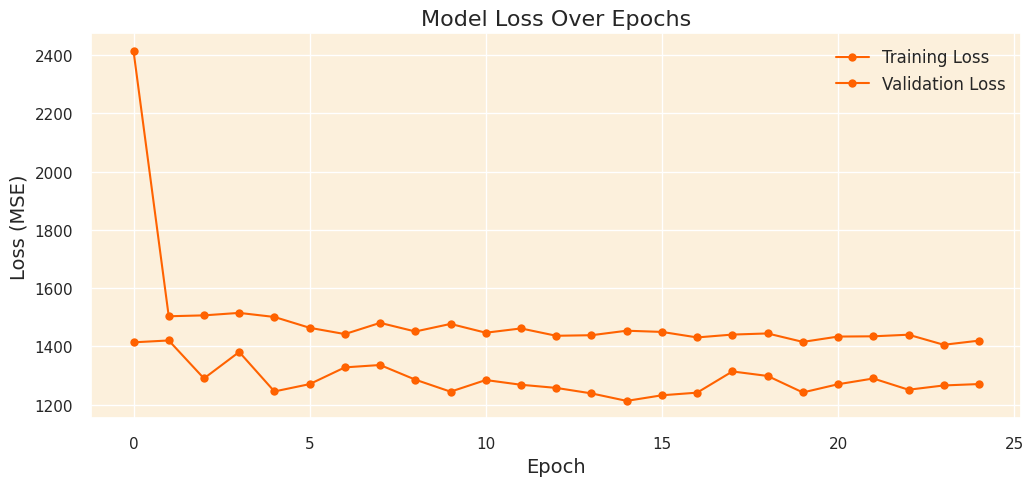

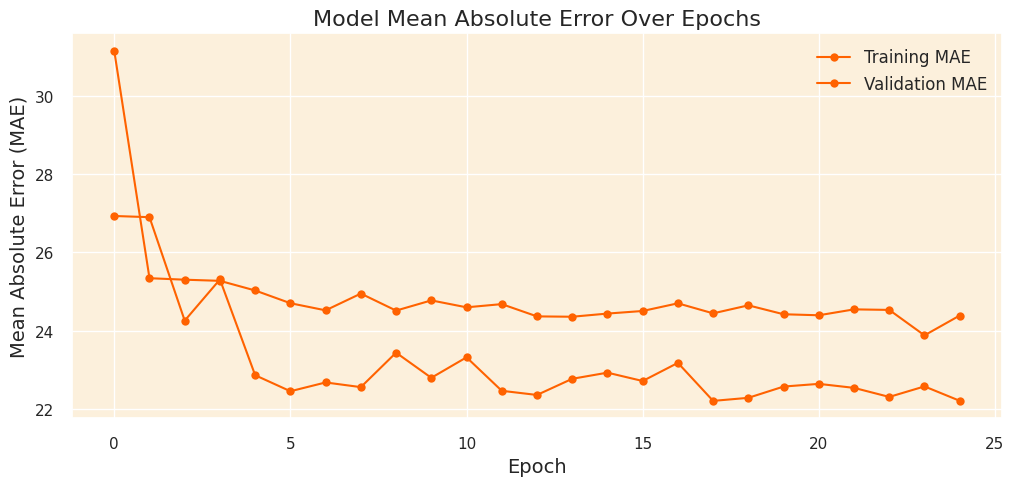

In [ ]:
# Visualize training history

# Plot Loss (MSE)
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss Over Epochs', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss (MSE)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# Plot Mean Absolute Error (MAE)
plt.figure(figsize=(12, 5))
plt.plot(history.history['mean_absolute_error'], label='Training MAE', marker='o')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE', marker='o')
plt.title('Model Mean Absolute Error Over Epochs', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Mean Absolute Error (MAE)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [ ]:
# Assuming X_test_scaled and y_test are prepared
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (MSE): {test_loss:.2f}")
print(f"Test MAE: {test_mae:.2f}")

Test Loss (MSE): 1287.58
Test MAE: 23.66


In [ ]:
# Predict on the test set
predictions = model.predict(X_test)

# Calculate min and max predictions
min_pred = predictions.min()
max_pred = predictions.max()

print(f"Minimum Predicted Price: {min_pred:.2f}")
print(f"Maximum Predicted Price: {max_pred:.2f}")

# Compare with actual prices
print(f"Minimum Actual Price: {y_test.min():.2f}")
print(f"Maximum Actual Price: {y_test.max():.2f}")

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Minimum Predicted Price: 4.86
Maximum Predicted Price: 256.38
Minimum Actual Price: 4.60
Maximum Actual Price: 196.90


##ANN PYTORCH


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np


In [ ]:
# Define the PyTorch model
class MLPModel(nn.Module):
    def __init__(self, input_dim):
        super(MLPModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 32)  # First dense layer with 32 units
        self.bn1 = nn.BatchNorm1d(32)        # Batch normalization layer
        self.dropout1 = nn.Dropout(0.3)      # Dropout layer with 30% drop probability
        self.fc2 = nn.Linear(32, 16)         # Second dense layer with 16 units
        self.dropout2 = nn.Dropout(0.2)      # Dropout layer with 20% drop probability
        self.fc3 = nn.Linear(16, 1)          # Output layer (regression)

    def forward(self, x):
        x = torch.relu(self.fc1(x))          # ReLU activation for first layer
        x = self.bn1(x)                      # Apply batch normalization
        x = self.dropout1(x)                 # Apply dropout
        x = torch.relu(self.fc2(x))          # ReLU activation for second layer
        x = self.dropout2(x)                 # Apply dropout
        x = self.fc3(x)                      # Output layer
        return x

In [ ]:
# Convert DataFrame to numpy arrays before converting to tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)  # Use .values to get a numpy array
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)  # Similarly for y_train

# Split the data into training and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train_tensor, y_train_tensor, test_size=0.2, random_state=42)

In [ ]:
# Create the model
input_dim = X_train.shape[1]  # The number of input features
model = MLPModel(input_dim)

# Define the loss function and optimizer
criterion = nn.MSELoss()  # For regression, use Mean Squared Error Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training the model
num_epochs = 100
for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    optimizer.zero_grad()  # Zero the gradients

    # Forward pass
    outputs = model(X_train_split)
    loss = criterion(outputs.squeeze(), y_train_split)  # Squeeze the output for loss computation

    # Backward pass and optimization
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:  # Print every 10 epochs
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')


Epoch [10/100], Loss: 4383.1821
Epoch [20/100], Loss: 4362.8545
Epoch [30/100], Loss: 4340.2236
Epoch [40/100], Loss: 4313.0059
Epoch [50/100], Loss: 4281.8052
Epoch [60/100], Loss: 4245.8647
Epoch [70/100], Loss: 4203.4883
Epoch [80/100], Loss: 4152.7710
Epoch [90/100], Loss: 4085.5146
Epoch [100/100], Loss: 4017.5208


In [ ]:
# Model evaluation
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    val_outputs = model(X_val_split)
    val_loss = criterion(val_outputs.squeeze(), y_val_split)
    print(f'Validation Loss: {val_loss.item():.4f}')

Validation Loss: 4334.1597


In [ ]:
# Convert X_test and y_test to PyTorch tensors
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)  # Convert to tensor
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)  # Convert to tensor

# Set the model to evaluation mode
model.eval()

# Make predictions on the test set
with torch.no_grad():  # No need to track gradients during prediction
    predictions = model(X_test_tensor)

# Convert predictions to numpy for easy manipulation
predictions = predictions.detach().numpy()

# Calculate min and max predictions
min_pred = predictions.min()
max_pred = predictions.max()

print(f"Minimum Predicted Price: {min_pred:.2f}")
print(f"Maximum Predicted Price: {max_pred:.2f}")

# Compare with actual prices
min_actual = y_test_tensor.numpy().min()  # Convert y_test_tensor to numpy
max_actual = y_test_tensor.numpy().max()

print(f"Minimum Actual Price: {min_actual:.2f}")
print(f"Maximum Actual Price: {max_actual:.2f}")

Minimum Predicted Price: -0.13
Maximum Predicted Price: 26.91
Minimum Actual Price: 4.60
Maximum Actual Price: 196.90
